# GNSS Dilution of Precision Validation

TAT-C's `compute_dop` computes the dilution of precision (DOP) of a navigation constellation at a ground point: how the geometry of the visible satellites amplifies ranging errors into errors of position (PDOP, or horizontal and vertical components HDOP and VDOP), receiver clock (TDOP), or both (GDOP). This notebook compares it with the geometry of the four global navigation satellite systems (GNSS), GPS, Galileo, BeiDou, and GLONASS, at six International GNSS Service (IGS) stations from 68 deg north to 78 deg south on 3 October 2026, and asks:

1. **Orbits.** How accurately do public two-line element (TLE) sets locate the navigation satellites?
2. **DOP computation.** Does `compute_dop` reproduce the DOP computed independently from the satellites' broadcast ephemerides, for the same satellites and for the operational constellations as published in TLEs?
3. **Tracked satellites.** How do TAT-C's visible satellites and DOP compare with the satellites the stations' receivers actually tracked?
4. **Multi-GNSS clocks.** Receivers combining systems estimate a clock (or time offset) per system; how does this affect the DOP of combined constellations, and does `compute_dop` reproduce it with a clock per system?
5. **Walker designs.** Do Walker constellations generated by TAT-C provide the DOP of the operational Galileo and BeiDou constellations they model (see [Orbit and Constellation Generation](ValidateOrbitGeneration.ipynb))?

## Reference Data

From the BKG GNSS Data Center (anonymous access), which mirrors IGS data:

* the **broadcast ephemerides** of all four systems merged by the IGS (`BRDC00IGS_R`, RINEX 3 navigation), which locate the satellites to a few meters and flag their health;
* the IGS **rapid orbits** of the GPS satellites (`IGS0OPSRAP`, SP3), accurate to a few centimeters, used to verify the broadcast ephemeris computation; and
* the daily **observation files** (RINEX 3, 30 s, Hatanaka-compressed) of six stations, which record the satellites each receiver tracked; reading them requires the `hatanaka` package.

TLEs of the four constellations are retrieved from [CelesTrak](https://celestrak.org/) (epochs of 3 and 4 October 2026). All data are cached in local `data/gnss` and `data/orbits` directories (about 32 MB).

In [1]:
from datetime import datetime, timedelta, timezone
from pathlib import Path
import gzip

import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "gnss"
ORBIT_DIR = Path("data") / "orbits"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ORBIT_DIR.mkdir(parents=True, exist_ok=True)
DAY = datetime(2026, 10, 3, tzinfo=timezone.utc)
BKG = "https://igs.bkg.bund.de/root_ftp/IGS"
STATIONS = ["KIR000SWE", "WTZR00DEU", "GUAM00GUM", "NKLG00GAB", "HOB200AUS", "MCM400ATA"]
FILES = {
    "BRDC00IGS_R_20262760000_01D_MN.rnx.gz": f"{BKG}/BRDC/2026/276/",
    "IGS0OPSRAP_20262760000_01D_15M_ORB.SP3.gz": f"{BKG}/products/2438/",
    **{f"{station}_R_20262760000_01D_30S_MO.crx.gz": f"{BKG}/obs/2026/276/" for station in STATIONS},
}
for name, base in FILES.items():
    if not (DATA_DIR / name).exists():
        response = requests.get(base + name, timeout=600)
        response.raise_for_status()
        (DATA_DIR / name).write_bytes(response.content)
SYSTEMS = {"G": ("GPS", "gps-ops"), "E": ("Galileo", "galileo"), "C": ("BeiDou", "beidou"), "R": ("GLONASS", "glo-ops")}
TLES = {}
for system, (label, group) in SYSTEMS.items():
    path = ORBIT_DIR / f"{group}.tle"
    if not path.exists():
        response = requests.get("https://celestrak.org/NORAD/elements/gp.php", params={"GROUP": group, "FORMAT": "tle"}, timeout=120)
        response.raise_for_status()
        path.write_text(response.text)
    lines = [line.rstrip() for line in path.read_text().splitlines() if line.strip()]
    TLES[system] = {lines[i].strip(): lines[i + 1 : i + 3] for i in range(0, len(lines) - 2, 3)}
pd.Series({label: len(TLES[system]) for system, (label, _) in SYSTEMS.items()}, name="satellites in TLE group")

GPS        32
Galileo    32
BeiDou     54
GLONASS    27
Name: satellites in TLE group, dtype: int64

The broadcast ephemerides are evaluated with each system's interface control document: Keplerian elements with harmonic corrections for GPS, Galileo, and BeiDou (including the rotation used for BeiDou's geostationary satellites), and numerical integration of the broadcast position, velocity, and lunisolar acceleration for GLONASS. Each satellite's nearest healthy ephemeris within its validity is used. The tracked satellites at an epoch are those with any pseudorange observation.

In [2]:
GPS_EPOCH = datetime(1980, 1, 6, tzinfo=timezone.utc)
BDT_EPOCH = datetime(2006, 1, 1, tzinfo=timezone.utc)
GPS_UTC = 18.0  # s (leap seconds, GPS time minus UTC)
BDT_GPS = -14.0  # s (BeiDou time minus GPS time)
CONSTANTS = {  # gravitational parameter (m^3/s^2) and Earth rotation rate (rad/s) of each system's ICD
    "G": (3.986005e14, 7.2921151467e-5),
    "E": (3.986004418e14, 7.2921151467e-5),
    "C": (3.986004418e14, 7.292115e-5),
}
BEIDOU_GEO = {1, 2, 3, 4, 5, 59, 60, 61, 62, 63}
NAV_LINES = {"G": 8, "E": 8, "C": 8, "J": 8, "I": 8, "R": 4, "S": 4}


def _float(text):
    text = text.strip().replace("D", "E").replace("d", "e")
    return float(text) if text else np.nan


def read_navigation(path):
    """Broadcast ephemeris records of GPS (G), Galileo (E), BeiDou (C), and GLONASS (R) satellites."""
    with gzip.open(path, "rt", errors="replace") as f:
        lines = f.read().splitlines()
    version = float(lines[0][:9])
    k = next(i for i, line in enumerate(lines) if "END OF HEADER" in line) + 1
    records = []
    nav_lines = dict(NAV_LINES, R=5 if version >= 3.05 else 4)
    while k < len(lines):
        line = lines[k]
        if not line.strip():
            k += 1
            continue
        system = line[0]
        count = nav_lines.get(system, 8)
        block = lines[k : k + count]
        k += count
        if system not in "GECR":
            continue
        prn = int(line[1:3])
        epoch = datetime(int(line[4:8]), int(line[9:11]), int(line[12:14]), int(line[15:17]), int(line[18:20]), int(line[21:23]), tzinfo=timezone.utc)
        values = [_float(line[23 + 19 * j : 42 + 19 * j]) for j in range(3)]
        for row in block[1:]:
            values += [_float(row[4 + 19 * j : 23 + 19 * j]) for j in range(4)]
        records.append((system, prn, epoch, values))
    return records


def _kepler_position(system, prn, v, t_system):
    """ECEF position (m) of a GPS/Galileo/BeiDou satellite at a time (seconds of the system's time scale since its epoch)."""
    mu, omega_e = CONSTANTS[system]
    crs, dn, m0 = v[4], v[5], v[6]
    cuc, e, cus, sqrt_a = v[7], v[8], v[9], v[10]
    toe, cic, omega0, cis = v[11], v[12], v[13], v[14]
    i0, crc, w, omega_dot = v[15], v[16], v[17], v[18]
    idot, week = v[19], v[21]
    epoch = GPS_EPOCH if system in "GE" else BDT_EPOCH
    week_seconds = week * 604800 if system == "C" else (week * 604800)
    tk = t_system - (week_seconds + toe)
    a = sqrt_a**2
    n = np.sqrt(mu / a**3) + dn
    m = m0 + n * tk
    ecc_anomaly = m
    for _ in range(10):
        ecc_anomaly = m + e * np.sin(ecc_anomaly)
    nu = np.arctan2(np.sqrt(1 - e**2) * np.sin(ecc_anomaly), np.cos(ecc_anomaly) - e)
    phi = nu + w
    u = phi + cus * np.sin(2 * phi) + cuc * np.cos(2 * phi)
    r = a * (1 - e * np.cos(ecc_anomaly)) + crs * np.sin(2 * phi) + crc * np.cos(2 * phi)
    i = i0 + cis * np.sin(2 * phi) + cic * np.cos(2 * phi) + idot * tk
    x, y = r * np.cos(u), r * np.sin(u)
    if system == "C" and prn in BEIDOU_GEO:
        omega = omega0 + omega_dot * tk - omega_e * toe
        xg = x * np.cos(omega) - y * np.cos(i) * np.sin(omega)
        yg = x * np.sin(omega) + y * np.cos(i) * np.cos(omega)
        zg = y * np.sin(i)
        f, c = np.radians(-5), omega_e * tk
        rx = np.array([[1, 0, 0], [0, np.cos(f), np.sin(f)], [0, -np.sin(f), np.cos(f)]])
        rz = np.array([[np.cos(c), np.sin(c), 0], [-np.sin(c), np.cos(c), 0], [0, 0, 1]])
        return rz @ rx @ np.array([xg, yg, zg])
    omega = omega0 + (omega_dot - omega_e) * tk - omega_e * toe
    return np.array([x * np.cos(omega) - y * np.cos(i) * np.sin(omega), x * np.sin(omega) + y * np.cos(i) * np.cos(omega), y * np.sin(i)])


def _glonass_position(v, dt):
    """ECEF position (m) of a GLONASS satellite dt seconds after its ephemeris epoch, by RK4 integration (PZ-90 model)."""
    mu, ae, j2, omega = 398600.4418e9, 6378136.0, 1.0826257e-3, 7.292115e-5
    state = np.array([v[3], v[7], v[11], v[4], v[8], v[12]]) * 1e3
    acc = np.array([v[5], v[9], v[13]]) * 1e3

    def derivative(s):
        x, y, z, vx, vy, vz = s
        r = np.sqrt(x * x + y * y + z * z)
        c = 1.5 * j2 * mu * ae**2 / r**5
        return np.array([
            vx, vy, vz,
            -mu * x / r**3 - c * x * (1 - 5 * z * z / r**2) + omega**2 * x + 2 * omega * vy + acc[0],
            -mu * y / r**3 - c * y * (1 - 5 * z * z / r**2) + omega**2 * y - 2 * omega * vx + acc[1],
            -mu * z / r**3 - c * z * (3 - 5 * z * z / r**2) + acc[2],
        ])

    steps = max(1, int(np.ceil(abs(dt) / 60)))
    h = dt / steps
    for _ in range(steps):
        k1 = derivative(state)
        k2 = derivative(state + h / 2 * k1)
        k3 = derivative(state + h / 2 * k2)
        k4 = derivative(state + h * k3)
        state = state + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return state[:3]


def healthy(record):
    system, _, _, v = record
    if system == "G":
        return v[24] == 0
    if system == "E":
        return int(v[24]) & 0b111111111 == 0 if np.isfinite(v[24]) else False
    if system == "C":
        return v[24] == 0
    if system == "R":
        return v[6] == 0
    return False


def broadcast_positions(records, times, only_healthy=True):
    """ECEF positions (m) of each satellite (keyed 'G01', ...) at UTC times, from the nearest ephemeris record (NaN if none within its validity)."""
    by_satellite = {}
    for record in records:
        if only_healthy and not healthy(record):
            continue
        by_satellite.setdefault(f"{record[0]}{record[1]:02d}", []).append(record)
    positions = {}
    for name, recs in by_satellite.items():
        system = name[0]
        validity = {"G": 4 * 3600, "E": 4 * 3600, "C": 2 * 3600, "R": 30 * 60}[system]
        out = np.full((len(times), 3), np.nan)
        epochs = np.array([(r[2] - GPS_EPOCH).total_seconds() for r in recs])
        for k, t in enumerate(times):
            t_gps = (t - GPS_EPOCH).total_seconds() + GPS_UTC
            if system == "R":
                # GLONASS ephemeris epochs are in UTC
                j = int(np.argmin(np.abs(epochs - (t - GPS_EPOCH).total_seconds())))
                dt = (t - recs[j][2]).total_seconds()
                if abs(dt) <= validity:
                    out[k] = _glonass_position(recs[j][3], dt)
                continue
            # GPS/Galileo/BeiDou epochs (time of clock) are in the system's own time scale
            offset = GPS_UTC + (BDT_GPS if system == "C" else 0)
            j = int(np.argmin(np.abs(epochs - ((t - GPS_EPOCH).total_seconds() + offset))))
            if abs(epochs[j] - ((t - GPS_EPOCH).total_seconds() + offset)) > validity:
                continue
            t_system = t_gps if system in "GE" else (t - BDT_EPOCH).total_seconds() + GPS_UTC + BDT_GPS
            out[k] = _kepler_position(system, recs[j][1], recs[j][3], t_system)
        positions[name] = out
    return positions


def read_sp3(path):
    """Precise positions (m) of each satellite at the SP3 epochs (GPS time), returned with the epochs converted to UTC."""
    epochs, data = [], {}
    with gzip.open(path, "rt") as f:
        for line in f:
            if line.startswith("*"):
                parts = line.split()
                gps = datetime(int(parts[1]), int(parts[2]), int(parts[3]), int(parts[4]), int(parts[5]), int(float(parts[6])), tzinfo=timezone.utc)
                epochs.append(gps - timedelta(seconds=GPS_UTC))
            elif line.startswith("P") and epochs:
                name = line[1:4].replace(" ", "0")
                data.setdefault(name, {})[len(epochs) - 1] = [float(line[4:18]) * 1e3, float(line[18:32]) * 1e3, float(line[32:46]) * 1e3]
    out = {}
    for name, values in data.items():
        array = np.full((len(epochs), 3), np.nan)
        for k, xyz in values.items():
            if abs(xyz[0]) > 1:
                array[k] = xyz
        out[name] = array
    return epochs, out


def interpolate_sp3(epochs, positions, times, order=9):
    """Lagrange interpolation of SP3 positions to UTC times."""
    t0 = epochs[0]
    x = np.array([(e - t0).total_seconds() for e in epochs])
    out = {}
    for name, p in positions.items():
        result = np.full((len(times), 3), np.nan)
        for k, t in enumerate(times):
            s = (t - t0).total_seconds()
            j = int(np.clip(np.searchsorted(x, s) - order // 2, 0, len(x) - order))
            xs, ps = x[j : j + order], p[j : j + order]
            if np.isnan(ps).any():
                continue
            weights = np.array([np.prod([(s - xs[m]) / (xs[i] - xs[m]) for m in range(order) if m != i]) for i in range(order)])
            result[k] = weights @ ps
        out[name] = result
    return out


def read_tracked(path, times):
    """Station position (m, from the header) and the satellites with a pseudorange observation at each of the given UTC times (GPS time in the file)."""
    import hatanaka

    text = hatanaka.decompress(open(path, "rb").read()).decode("ascii", errors="replace")
    lines = text.splitlines()
    position = None
    types = {}
    k = 0
    current = None
    while "END OF HEADER" not in lines[k]:
        line = lines[k]
        label = line[60:].strip()
        if label == "APPROX POSITION XYZ":
            position = np.array([float(line[0:14]), float(line[14:28]), float(line[28:42])])
        if label == "SYS / # / OBS TYPES":
            if line[0] != " ":
                current = line[0]
                types[current] = line[7:60].split()
            else:
                types[current] += line[7:60].split()
        k += 1
    wanted = {round((t - GPS_EPOCH).total_seconds() + GPS_UTC) for t in times}
    tracked = {}
    k += 1
    while k < len(lines):
        line = lines[k]
        if line.startswith(">"):
            count = int(line[32:35])
            epoch = datetime(int(line[2:6]), int(line[7:9]), int(line[10:12]), int(line[13:15]), int(line[16:18]), int(float(line[19:29])), tzinfo=timezone.utc)
            key = round((epoch - GPS_EPOCH).total_seconds())
            if key in wanted and int(line[31]) in (0, 1):
                sats = set()
                for row in lines[k + 1 : k + 1 + count]:
                    system = row[0]
                    if system not in types:
                        continue
                    codes = types[system]
                    for j, code in enumerate(codes):
                        if code.startswith("C"):
                            field = row[3 + 16 * j : 3 + 16 * j + 14].strip()
                            if field:
                                sats.add(row[0:3].replace(" ", "0"))
                                break
                tracked[epoch - timedelta(seconds=GPS_UTC)] = sats
            k += 1 + count
        else:
            k += 1
    return position, tracked

## Setup

The analysis samples the day every 5 minutes, at times aligned with the stations' observation epochs (in GPS time, 18 s ahead of UTC). Broadcast positions of the healthy satellites, the stations' positions (from their observation file headers), and the satellites they tracked are read at these times. Each TLE is matched to a healthy broadcast satellite (identified by its pseudo-random noise code, PRN): by the PRN in its name for GPS, and as the nearest satellite at noon (within 100 km) for Galileo, BeiDou, and GLONASS, whose TLE names do not reliably give the PRN.

In [3]:
import re

import matplotlib.pyplot as plt
from pyproj import Transformer
from skyfield.framelib import itrs

from tatc.analysis import DopMethod, collect_multi_observations, compute_dop  # noqa: F401
from tatc.constants import EARTH_MEAN_RADIUS, timescale
from tatc.schemas import CircularOrbit, GeneralPerturbationsOrbit, Point, Satellite, WalkerConstellation

TIMES = [DAY + timedelta(minutes=5 * k, seconds=-GPS_UTC) for k in range(1, 289)]
MASK = 10  # deg
records = read_navigation(DATA_DIR / "BRDC00IGS_R_20262760000_01D_MN.rnx.gz")
broadcast = broadcast_positions(records, TIMES)
to_geodetic = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
stations = {}
for station in STATIONS:
    xyz, tracked = read_tracked(DATA_DIR / f"{station}_R_20262760000_01D_30S_MO.crx.gz", TIMES)
    lon, lat, height = to_geodetic.transform(*xyz)
    stations[station[:4]] = {"xyz": xyz, "lat": lat, "lon": lon, "height": height, "tracked": tracked}
# TAT-C satellites from TLEs, their Earth-fixed positions, and their PRNs
satellites, tle_positions, prn = {}, {}, {}
sk_times = timescale.from_datetimes(TIMES)
for system in SYSTEMS:
    for name, (line1, line2) in TLES[system].items():
        sat = Satellite(name=name, orbit=GeneralPerturbationsOrbit.from_tle([line1, line2]))
        position = np.array(sat.orbit.to_gp_orbit().get_orbit_track_at_time(sk_times).frame_xyz(itrs).m).T
        satellites[name], tle_positions[name] = sat, position
        code = re.search(r"\(PRN (\d+)\)", name) if system == "G" else None
        if code is not None:
            if f"{system}{int(code.group(1)):02d}" in broadcast:
                prn[name] = f"{system}{int(code.group(1)):02d}"
            continue
        candidates = {s: np.linalg.norm(p[144] - position[144]) for s, p in broadcast.items() if s[0] == system and np.isfinite(p[144]).all()}
        if candidates and min(candidates.values()) < 100e3:
            prn[name] = min(candidates, key=candidates.get)
pd.DataFrame(
    {
        label: {
            "TLEs": len(TLES[system]),
            "healthy broadcast satellites": sum(s[0] == system for s in broadcast),
            "TLEs matched to healthy satellites": sum(p[0] == system for p in prn.values()),
        }
        for system, (label, _) in SYSTEMS.items()
    }
).T

,TLEs,healthy broadcast satellites,TLEs matched to healthy satellites
GPS,32,32,32
Galileo,32,28,28
BeiDou,54,37,36
GLONASS,27,24,23


In [4]:
BLUE, ORANGE, AQUA, GRAY, INK, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#8e5bd8"
SYSTEM_COLORS = {"G": BLUE, "E": ORANGE, "C": AQUA, "R": PURPLE}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})


def enu_matrix(lat, lon):
    lat, lon = np.radians(lat), np.radians(lon)
    return np.array([
        [-np.sin(lon), np.cos(lon), 0],
        [-np.sin(lat) * np.cos(lon), -np.sin(lat) * np.sin(lon), np.cos(lat)],
        [np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)],
    ])


def reference_dop(station, positions, mask=MASK, clocks="single", subsets=None):
    """DOP from satellite positions (dict of (times, 3) arrays) at a station, computed independently in the local east-north-up frame.

    clocks: 'single' (one receiver clock, as in compute_dop) or 'system' (one clock per GNSS system).
    subsets: optional list (per time) of the satellite names to use."""
    s = stations[station]
    rotation = enu_matrix(s["lat"], s["lon"])
    rows = []
    for k in range(len(TIMES)):
        names = [n for n in positions if np.isfinite(positions[n][k]).all() and (subsets is None or n in subsets[k])]
        if not names:
            rows.append({"n": 0})
            continue
        los = np.array([positions[n][k] for n in names]) - s["xyz"]
        e = (rotation @ (los / np.linalg.norm(los, axis=1, keepdims=True)).T).T
        visible = np.degrees(np.arcsin(e[:, 2])) >= mask
        e = e[visible]
        systems = sorted({n[0] for n, v in zip(names, visible) if v})
        if clocks == "system":
            columns = [[1.0 if n[0] == system else 0.0 for n, v in zip(names, visible) if v] for system in systems]
            h = np.column_stack([e] + [np.array(c) for c in columns])
        else:
            h = np.column_stack([e, np.ones(len(e))])
        if len(e) < h.shape[1]:
            rows.append({"n": len(e)})
            continue
        q = np.linalg.inv(h.T @ h)
        rows.append({"n": len(e), "HDOP": np.sqrt(q[0, 0] + q[1, 1]), "VDOP": np.sqrt(q[2, 2]), "PDOP": np.sqrt(np.trace(q[:3, :3])), "TDOP": np.sqrt(q[3, 3])})
    return pd.DataFrame(rows, index=TIMES)


def tatc_dop(station, names, mask=MASK, systems=None):
    """DOP from compute_dop for TAT-C satellites (by name) at a station, optionally with a clock per system (systems: label per satellite)."""
    s = stations[station]
    point = Point(id=0, latitude=s["lat"], longitude=s["lon"], elevation=s["height"])
    sats = [satellites[n] for n in names]
    out = {method.value.upper(): compute_dop(TIMES, point, sats, mask, method, systems=systems).dop.to_numpy() for method in [DopMethod.PDOP, DopMethod.HDOP, DopMethod.VDOP, DopMethod.TDOP]}
    return pd.DataFrame(out, index=TIMES)


def relative(a, b):
    """Relative difference of DOP values, where both are defined."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    return (a[ok] - b[ok]) / b[ok]

## Test 1: Orbits

The broadcast ephemeris computation is first verified against the IGS rapid orbits of the GPS satellites. TAT-C's positions (SGP4 propagation of the TLEs) are then compared with the broadcast positions of the matched satellites over the day.

In [5]:
sp3_epochs, sp3 = read_sp3(DATA_DIR / "IGS0OPSRAP_20262760000_01D_15M_ORB.SP3.gz")
sp3_positions = interpolate_sp3(sp3_epochs, sp3, TIMES[::6])
check = np.concatenate([np.linalg.norm(broadcast[s][::6] - sp3_positions[s], axis=1) for s in sp3_positions if s in broadcast])
check = check[np.isfinite(check)]
rows1 = {"GPS broadcast vs. IGS rapid (m)": {"satellites": len([s for s in sp3_positions if s in broadcast]), "median": np.median(check), "p95": np.percentile(check, 95), "max": check.max()}}
for system, (label, _) in SYSTEMS.items():
    errors = np.concatenate([np.linalg.norm(tle_positions[n] - broadcast[p], axis=1) for n, p in prn.items() if p[0] == system]) / 1e3
    errors = errors[np.isfinite(errors)]
    rows1[f"{label} TLE vs. broadcast (km)"] = {"satellites": sum(p[0] == system for p in prn.values()), "median": np.median(errors), "p95": np.percentile(errors, 95), "max": errors.max()}
pd.DataFrame(rows1).T.round(2)

,satellites,median,p95,max
GPS broadcast vs. IGS rapid (m),32.0,1.79,2.90,3.86
GPS TLE vs. broadcast (km),32.0,1.80,349.47,875.16
Galileo TLE vs. broadcast (km),28.0,0.89,6.86,16.35
BeiDou TLE vs. broadcast (km),36.0,0.51,2.36,6.10
GLONASS TLE vs. broadcast (km),23.0,0.46,1.32,2.44


The broadcast ephemeris computation agrees with the IGS rapid orbits to 1.8 m (median) and 3.9 m (maximum), so the broadcast positions are an accurate reference at the scale of TLE errors. The TLEs locate the navigation satellites to about 1 km (median: 1.8 km for GPS, 0.9 km for Galileo, 0.5 km for BeiDou and GLONASS), a direction error of less than 0.01 deg from the ground, at ranges of 20,000 km or more. Two GPS element sets are much worse: PRN 13 (GPS III-10, launched in 2026, whose element set is 13 days old) is 875 km from its broadcast position, and PRN 25, whose element set is current, 350 km, possibly from a recent maneuver or a change of PRN.

## Test 2: DOP Computation

At each station, `compute_dop` (with a 10 deg elevation mask) is compared with the DOP computed independently from the broadcast positions (with the same mask and a single receiver clock), for each system and for all four combined:

* **same satellites**: TAT-C uses only the TLEs matched to healthy broadcast satellites, so differences come from the computation and the TLEs' orbit errors;
* **TLE groups**: TAT-C uses every satellite in the systems' TLE groups, as a user modeling the operational constellations would, while the reference uses the healthy satellites.

In [6]:
COMBINATIONS = {"GPS": "G", "Galileo": "E", "BeiDou": "C", "GLONASS": "R", "all four": "GECR"}
rows2, series2 = {}, {}
for label, systems in COMBINATIONS.items():
    matched = [n for n, p in prn.items() if p[0] in systems]
    group = [n for n in satellites if any(n in TLES[s] for s in systems)]
    reference_positions = {p: broadcast[p] for p in broadcast if p[0] in systems}
    matched_positions = {prn[n]: broadcast[prn[n]] for n in matched}
    pooled = {"same": [], "group": []}
    for station in stations:
        reference = reference_dop(station, reference_positions)
        reference_same = reference_dop(station, matched_positions)
        same = tatc_dop(station, matched)
        tatc_group = tatc_dop(station, group)
        pooled["same"].append(relative(same.PDOP, reference_same.PDOP))
        pooled["group"].append(relative(tatc_group.PDOP, reference.PDOP))
        series2[(label, station)] = (reference, same, tatc_group)
    same_all, group_all = np.concatenate(pooled["same"]), np.concatenate(pooled["group"])
    rows2[label] = {
        "TLEs / healthy satellites / matched": f"{len(group)} / {len(reference_positions)} / {len(matched)}",
        "PDOP difference, same satellites, median |x| (%)": 100 * np.median(np.abs(same_all)),
        "PDOP difference, same satellites, p95 |x| (%)": 100 * np.percentile(np.abs(same_all), 95),
        "PDOP difference, TLE groups, median (%)": 100 * np.median(group_all),
        "PDOP difference, TLE groups, p95 |x| (%)": 100 * np.percentile(np.abs(group_all), 95),
        "median PDOP (reference)": np.nanmedian(np.concatenate([series2[(label, st)][0].PDOP.to_numpy(dtype=float) for st in stations])),
    }
pd.DataFrame(rows2).T.round(2)

,TLEs / healthy satellites / matched,"PDOP difference, same satellites, median |x| (%)","PDOP difference, same satellites, p95 |x| (%)","PDOP difference, TLE groups, median (%)","PDOP difference, TLE groups, p95 |x| (%)",median PDOP (reference)
GPS,32 / 32 / 32,0.010033,0.802754,-0.000693,0.802754,1.803311
Galileo,32 / 28 / 28,0.004309,0.019675,-5.250266,21.511911,2.002512
BeiDou,54 / 37 / 36,0.001233,0.003871,-15.75421,31.056059,1.716994
GLONASS,27 / 24 / 23,0.001313,0.006029,-3.974782,20.971838,2.145445
all four,145 / 121 / 119,0.003296,0.341329,-8.39105,14.271333,0.849372


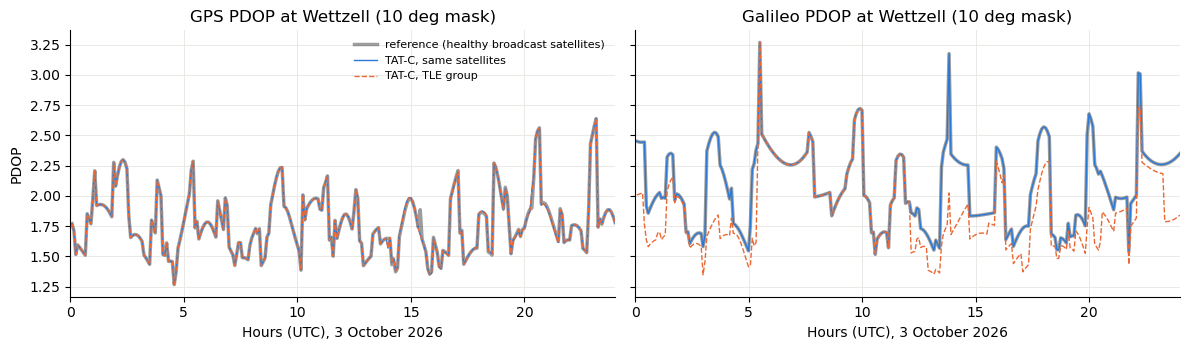

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, label in zip(axes, ["GPS", "Galileo"]):
    reference, same, group = series2[(label, "WTZR")]
    hours = [(t - DAY) / timedelta(hours=1) for t in TIMES]
    ax.plot(hours, reference.PDOP, color=INK, lw=2.5, alpha=0.4, label="reference (healthy broadcast satellites)")
    ax.plot(hours, same.PDOP, color=BLUE, lw=1, label="TAT-C, same satellites")
    ax.plot(hours, group.PDOP, color=ORANGE, lw=1, ls="--", label="TAT-C, TLE group")
    ax.set(xlabel="Hours (UTC), 3 October 2026", title=f"{label} PDOP at Wettzell (10 deg mask)", xlim=(0, 24))
axes[0].set_ylabel("PDOP")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

For the same satellites, `compute_dop` reproduces the independent computation to 0.01% (median) and 0.02% (95th percentile) for Galileo, BeiDou, and GLONASS: its geometry, frames, and DOP definitions are correct. For GPS, the two inaccurate element sets of Test 1 shift the 95th percentile to 0.8%.

The systems' TLE groups, however, contain more satellites than are healthy: 32 Galileo TLEs for 28 healthy satellites (including E14 and E18, in eccentric orbits and flagged unhealthy), 54 BeiDou TLEs for 37 (many of the others are older BeiDou-2 satellites), and 27 GLONASS TLEs for 24, the remainder having no healthy ephemerides in the merged broadcast file. Using every TLE in a group, TAT-C's DOP is 4 to 16% lower (median) than that of the healthy satellites, and up to 31% lower at times (95th percentile). The GPS group contains only the 32 healthy satellites and matches. A constellation should therefore be modeled with its operational satellites, not with all satellites in a TLE group.

## Test 3: Tracked Satellites

The satellites a station tracks depend on its receiver and antenna (the signals it is configured to track, and its elevation cutoff) and surroundings (obstructions). For each station and system, the fraction of the satellites above the horizon (from the healthy broadcast positions) that the receiver tracked is computed in elevation bins, and the PDOP of the tracked satellites above 10 deg is compared with TAT-C's PDOP (TLE groups, 10 deg mask).

In [8]:
BINS = np.array([0, 5, 10, 20, 30, 60, 90])
rows3, fraction3 = {}, {}
for station, s in stations.items():
    rotation = enu_matrix(s["lat"], s["lon"])
    counts = {system: np.zeros((2, len(BINS) - 1)) for system in SYSTEMS}
    for k, t in enumerate(TIMES):
        tracked = s["tracked"].get(t, set())
        for name, p in broadcast.items():
            if not np.isfinite(p[k]).all():
                continue
            los = p[k] - s["xyz"]
            elevation = np.degrees(np.arcsin((rotation @ (los / np.linalg.norm(los)))[2]))
            if elevation < 0:
                continue
            b = np.searchsorted(BINS, elevation, side="right") - 1
            counts[name[0]][0, b] += 1
            counts[name[0]][1, b] += name in tracked
    fraction3[station] = {system: c[1] / np.maximum(c[0], 1) for system, c in counts.items()}
    tracked_sets = [s["tracked"].get(t, set()) for t in TIMES]
    tracked_dop = reference_dop(station, broadcast, subsets=tracked_sets)
    _, _, group = series2[("all four", station)]
    rows3[station] = {
        "latitude (deg)": s["lat"],
        **{f"{SYSTEMS[sys][0]} tracked above 10 deg (%)": 100 * c[1, 2:].sum() / max(c[0, 2:].sum(), 1) for sys, c in counts.items()},
        "satellites tracked above 10 deg (mean)": tracked_dop.n.mean(),
        "PDOP, tracked (median)": np.nanmedian(tracked_dop.PDOP.to_numpy(dtype=float)),
        "PDOP, healthy (median)": np.nanmedian(series2[("all four", station)][0].PDOP.to_numpy(dtype=float)),
        "PDOP, TAT-C (median)": np.nanmedian(group.PDOP.to_numpy(dtype=float)),
    }
table3 = pd.DataFrame(rows3).T
table3.round(2)

,latitude (deg),GPS tracked above 10 deg (%),Galileo tracked above 10 deg (%),BeiDou tracked above 10 deg (%),GLONASS tracked above 10 deg (%),satellites tracked above 10 deg (mean),"PDOP, tracked (median)","PDOP, healthy (median)","PDOP, TAT-C (median)"
KIR0,67.88,99.67,99.67,96.57,99.66,38.48,0.88,0.87,0.80
WTZR,49.14,99.66,97.94,96.79,94.96,33.11,0.85,0.85,0.77
GUAM,13.59,97.76,98.72,96.69,99.48,41.15,0.79,0.78,0.69
NKLG,0.35,99.66,99.58,97.96,99.65,36.09,0.85,0.85,0.80
HOB2,-42.80,99.69,99.66,96.99,99.70,37.73,0.83,0.82,0.74
MCM4,-77.84,99.61,99.64,96.73,99.63,39.90,0.93,0.92,0.86


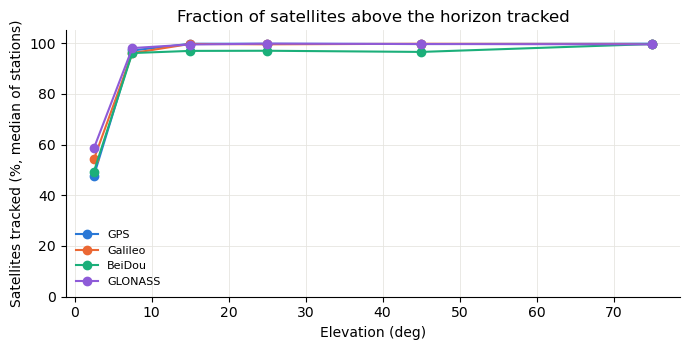

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.6))
centers = (BINS[:-1] + BINS[1:]) / 2
for system, (label, _) in SYSTEMS.items():
    values = np.array([fraction3[station][system] for station in stations])
    ax.plot(centers, 100 * np.median(values, axis=0), "o-", color=SYSTEM_COLORS[system], label=label)
ax.set(xlabel="Elevation (deg)", ylabel="Satellites tracked (%, median of stations)", title="Fraction of satellites above the horizon tracked", ylim=(0, 105))
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

The stations' receivers track 99 to 100% of the satellites above 10 deg elevation, with a few exceptions (96 to 98% of BeiDou satellites, 98% of GPS satellites at Guam and of Galileo satellites at Wettzell, and 95% of GLONASS satellites at Wettzell), and about 97% between 5 and 10 deg; below 5 deg, receiver cutoffs and obstructions leave about half untracked. Above TAT-C's 10 deg mask, the tracked satellites give the same DOP as the healthy satellites (combined PDOP 0.79 to 0.93, within 0.01): the satellites receivers miss hardly change the geometry. TAT-C's DOP with every TLE in the groups is 6 to 12% lower, as in Test 2.

## Test 4: Multi-GNSS Clocks

Each system keeps its own time, so a receiver combining several systems estimates a clock offset for each (or, equivalently, one clock and the inter-system offsets), using up one measurement per additional system. The reference DOP of combined constellations is computed both ways, from the healthy broadcast satellites, and compared with TAT-C's: by default, `compute_dop` estimates one clock; with the `systems` argument (each satellite's system), it estimates a clock per system.

In [10]:
rows4 = {}
for label, systems in {"GPS + Galileo": "GE", "GPS + GLONASS": "GR", "all four": "GECR"}.items():
    positions = {p: broadcast[p] for p in broadcast if p[0] in systems}
    names = [n for n, p in prn.items() if p[0] in systems]
    matched_positions = {prn[n]: broadcast[prn[n]] for n in names}
    single, system_clocks, tatc_values, tatc_system_values, same_one, same_system = [], [], [], [], [], []
    for station in stations:
        same_one.append(reference_dop(station, matched_positions).PDOP.to_numpy(dtype=float))
        same_system.append(reference_dop(station, matched_positions, clocks="system").PDOP.to_numpy(dtype=float))
        single.append(reference_dop(station, positions).PDOP.to_numpy(dtype=float))
        system_clocks.append(reference_dop(station, positions, clocks="system").PDOP.to_numpy(dtype=float))
        tatc_values.append(tatc_dop(station, names).PDOP.to_numpy(dtype=float))
        tatc_system_values.append(tatc_dop(station, names, systems=[prn[n][0] for n in names]).PDOP.to_numpy(dtype=float))
    single, system_clocks, tatc_values, tatc_system_values, same_one, same_system = (np.concatenate(v) for v in (single, system_clocks, tatc_values, tatc_system_values, same_one, same_system))
    rows4[label] = {
        "PDOP, one clock (median)": np.nanmedian(single),
        "PDOP, clock per system (median)": np.nanmedian(system_clocks),
        "clock per system minus one clock, median (%)": 100 * np.median(relative(system_clocks, single)),
        "clock per system minus one clock, p95 (%)": 100 * np.percentile(relative(system_clocks, single), 95),
        "TAT-C one clock minus clock per system, median (%)": 100 * np.median(relative(tatc_values, system_clocks)),
        "same satellites, one clock: TAT-C minus reference, median |x| (%)": 100 * np.median(np.abs(relative(tatc_values, same_one))),
        "same satellites, one clock: TAT-C minus reference, p95 |x| (%)": 100 * np.percentile(np.abs(relative(tatc_values, same_one)), 95),
        "same satellites, clock per system: TAT-C minus reference, median |x| (%)": 100 * np.median(np.abs(relative(tatc_system_values, same_system))),
        "same satellites, clock per system: TAT-C minus reference, p95 |x| (%)": 100 * np.percentile(np.abs(relative(tatc_system_values, same_system)), 95),
    }
pd.DataFrame(rows4).T.round(2)

,"PDOP, one clock (median)","PDOP, clock per system (median)","clock per system minus one clock, median (%)","clock per system minus one clock, p95 (%)","TAT-C one clock minus clock per system, median (%)","same satellites, one clock: TAT-C minus reference, median |x| (%)","same satellites, one clock: TAT-C minus reference, p95 |x| (%)","same satellites, clock per system: TAT-C minus reference, median |x| (%)","same satellites, clock per system: TAT-C minus reference, p95 |x| (%)"
GPS + Galileo,1.25,1.27,0.68,3.76,-0.68,0.01,0.43,0.01,0.39
GPS + GLONASS,1.28,1.30,0.94,5.81,-0.58,0.00,0.59,0.01,0.52
all four,0.85,0.87,1.84,5.51,-1.33,0.00,0.34,0.00,0.29


Estimating a clock per system raises the combined PDOP by 0.7 to 1.8% (median) and up to 6% (95th percentile), because each additional clock uses one of the measurements; with 20 to 40 satellites in view, this matters little. By default, `compute_dop` estimates a single clock and so underestimates the DOP of combined constellations by about 1%. With the `systems` argument, it estimates a clock per system and reproduces the independent computation for the same satellites to 0.01% (median); the 95th percentile (0.3 to 0.5%) is the same as with one clock, from the orbit errors of two GPS element sets (Test 1).

## Test 5: Walker Designs

Galileo and BeiDou-3's medium Earth orbit (MEO) satellites follow Walker 24/3/1 patterns ([Orbit and Constellation Generation](ValidateOrbitGeneration.ipynb)). For each, a `WalkerConstellation` is fitted to the healthy satellites in nominal orbits (as in that notebook), and the DOP of its 24 satellites (`compute_dop`, 10 deg mask) is compared with that of the operational satellites closest to its slots.

In [11]:
def fit_walker(names, total=24, planes=3):
    """Fit a Walker delta constellation to satellites (TAT-C names), as in the orbit generation notebook."""
    track = [satellites[n].orbit.to_gp_orbit().get_orbit_track_at_time(sk_times[144]) for n in names]
    elements = []
    for g in track:
        r, v = g.position.m, g.velocity.m_per_s
        h = np.cross(r, v)
        raan = np.degrees(np.arctan2(h[0], -h[1])) % 360
        node = np.array([np.cos(np.radians(raan)), np.sin(np.radians(raan)), 0])
        u = np.degrees(np.arctan2(np.dot(np.cross(node, r), h) / np.linalg.norm(h), np.dot(node, r))) % 360
        elements.append((np.degrees(np.arccos(h[2] / np.linalg.norm(h))), raan, u, np.linalg.norm(r)))
    inc, raan, u, radius = (np.array(x) for x in zip(*elements))
    wrap = lambda x: (x + 180) % 360 - 180
    best = None
    for spacing in range(planes):
        offset_u = offset_raan = 0.0
        for _ in range(4):
            lead = CircularOrbit(mean_altitude=float(np.median(radius)) - EARTH_MEAN_RADIUS, inclination=float(np.median(inc)), right_ascension_ascending_node=float(raan[0] + offset_raan) % 360, true_anomaly=float(u[0] + offset_u) % 360, epoch=TIMES[144])
            walker = WalkerConstellation(name="walker", orbit=lead, number_satellites=total, number_planes=planes, relative_spacing=spacing)
            members = walker.generate_members()
            d_raan = wrap(raan[:, None] - np.array([m.orbit.get_right_ascension_ascending_node() for m in members])[None, :])
            d_u = wrap(u[:, None] - np.array([m.orbit.true_anomaly for m in members])[None, :])
            slot = np.argmin(np.hypot(d_raan * np.sin(np.radians(np.median(inc))), d_u), axis=1)
            du, dr = d_u[np.arange(len(slot)), slot], d_raan[np.arange(len(slot)), slot]
            offset_u += float(np.median(du))
            offset_raan += float(np.median(dr))
        if best is None or np.median(np.abs(du)) < best[0]:
            best = (np.median(np.abs(du)), members, slot, np.abs(du))
    _, members, slot, cost = best
    closest = pd.Series(cost).groupby(slot).idxmin()
    return members, [names[i] for i in closest.to_numpy()]


rows5, cdf5 = {}, {}
for label, system in [("Galileo", "E"), ("BeiDou-3 MEO", "C")]:
    names = [n for n, p in prn.items() if p[0] == system]
    if system == "C":
        names = [n for n in names if abs(satellites[n].orbit.to_gp_orbit().elements[0].mean_motion * 86400 / 360 - 1.86) < 0.05]
    members, in_slots = fit_walker(names)
    for m in members:
        satellites[f"{label} Walker {m.name}"] = m
    walker_names = [f"{label} Walker {m.name}" for m in members]
    walker_values, real_values = [], []
    for station in stations:
        walker_values.append(tatc_dop(station, walker_names).PDOP.to_numpy(dtype=float))
        real_values.append(tatc_dop(station, in_slots).PDOP.to_numpy(dtype=float))
    walker_values, real_values = np.concatenate(walker_values), np.concatenate(real_values)
    cdf5[label] = (real_values, walker_values)
    rows5[label] = {
        "operational satellites in slots": len(in_slots),
        "PDOP, operational (median)": np.nanmedian(real_values),
        "PDOP, Walker (median)": np.nanmedian(walker_values),
        "PDOP, operational (p95)": np.nanpercentile(real_values, 95),
        "PDOP, Walker (p95)": np.nanpercentile(walker_values, 95),
        "times without a solution, operational (%)": 100 * np.mean(~np.isfinite(real_values)),
        "times without a solution, Walker (%)": 100 * np.mean(~np.isfinite(walker_values)),
    }
pd.DataFrame(rows5).T.round(2)

,operational satellites in slots,"PDOP, operational (median)","PDOP, Walker (median)","PDOP, operational (p95)","PDOP, Walker (p95)","times without a solution, operational (%)","times without a solution, Walker (%)"
Galileo,24.0,2.23,2.23,2.72,2.70,0.0,0.0
BeiDou-3 MEO,23.0,2.29,2.25,3.41,3.09,0.0,0.0


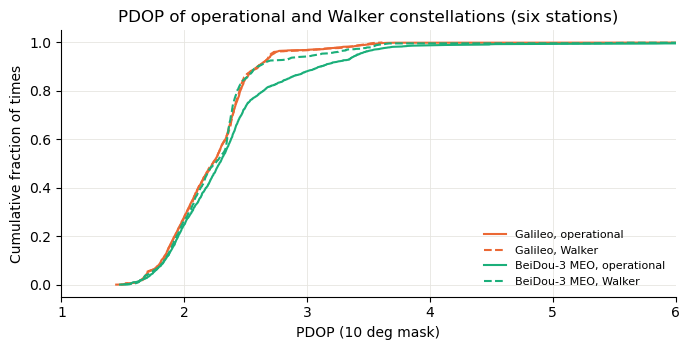

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for (label, (real_values, walker_values)), color in zip(cdf5.items(), [ORANGE, AQUA]):
    for values, ls, kind in [(real_values, "-", "operational"), (walker_values, "--", "Walker")]:
        v = np.sort(values[np.isfinite(values)])
        ax.plot(v, np.arange(1, len(v) + 1) / len(values), color=color, ls=ls, label=f"{label}, {kind}")
ax.set(xlabel="PDOP (10 deg mask)", ylabel="Cumulative fraction of times", xlim=(1, 6), title="PDOP of operational and Walker constellations (six stations)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

The Walker constellations provide the DOP of the operational constellations they model: for Galileo, a median PDOP of 2.23 for both and a 95th percentile of 2.70 versus 2.72. For BeiDou-3, whose operational satellites occupy 23 of the 24 slots, the medians agree (2.25 versus 2.29), but the empty slot raises the operational constellation's 95th percentile (3.41 versus 3.09). Unlike the daily average numbers of visible satellites in the orbit generation notebook, the instantaneous DOP depends on how satellites are phased, so this agreement confirms that the Walker phasing represents these constellations.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbits (TLE vs. broadcast ephemerides) | about 1 km (median) for all four systems; two GPS element sets 350 and 875 km off |
| 2. DOP computation (`compute_dop`) | same satellites: within 0.01% (median) of an independent computation; TLE groups: DOP 4 to 16% too low (median) for Galileo, BeiDou, and GLONASS, whose groups include satellites without healthy broadcast ephemerides |
| 3. Tracked satellites | receivers track 95 to 100% of satellites above 10 deg; DOP of tracked satellites within 0.01 of that of healthy satellites |
| 4. Multi-GNSS clocks | a clock per system raises combined PDOP by about 1% (up to 6%) over a single clock; `compute_dop` with `systems` reproduces it to 0.01% (median) |
| 5. Walker designs | Galileo and BeiDou-3 Walker 24/3/1 constellations reproduce the operational PDOP distributions (medians within 0.04) |

**DOP computation.** `compute_dop` computes the DOP of a constellation's geometry correctly, and the TLE errors of navigation satellites (about 1 km) do not affect it. The DOP that a receiver above a 10 deg mask experiences is that of the healthy satellites, which it tracks nearly completely.

**Modeling constellations.** The main source of error is the satellites included: TLE groups of navigation satellites contain satellites without healthy broadcast ephemerides (unhealthy, older, or not yet operational satellites), which make the computed DOP optimistic by 4 to 16%. Constellations should be modeled with their operational satellites (for example, those with healthy broadcast ephemerides, or the slots of their Walker patterns). For combined constellations, `compute_dop` estimates a single receiver clock by default and so underestimates DOP by about 1%; labeling each satellite's system (`systems`) estimates a clock per system, as multi-GNSS receivers do, and removes this small bias.